In [1]:
import numpy as np
import matplotlib.pyplot as plt
import cv2
import pydicom
import tensorflow as tf
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input, decode_predictions

def load_dicom_image(dicom_path, target_size=(224, 224)):
    dicom = pydicom.dcmread(dicom_path)
    img = dicom.pixel_array.astype(np.float32)

    # Normalize 0–255 for visibility
    img = (img - np.min(img)) / (np.max(img) - np.min(img)) * 255.0
    img = img.astype(np.uint8)

    # Resize and convert to 3 channels
    img_resized = cv2.resize(img, target_size)
    img_rgb = cv2.cvtColor(img_resized, cv2.COLOR_GRAY2RGB)
    img_input = np.expand_dims(img_rgb, axis=0)
    img_input = preprocess_input(img_input)  # for ResNet50
    return img_input, img_resized

model = ResNet50(weights='imagenet')
last_conv_layer = 'conv5_block3_out'

2025-06-04 09:41:34.521711: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1749030094.809616      35 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1749030094.890927      35 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-06-04 09:41:52.010346: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:152] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


102967424/102967424 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Top Prediction: ('n02769748', 'backpack', 0.3939429)


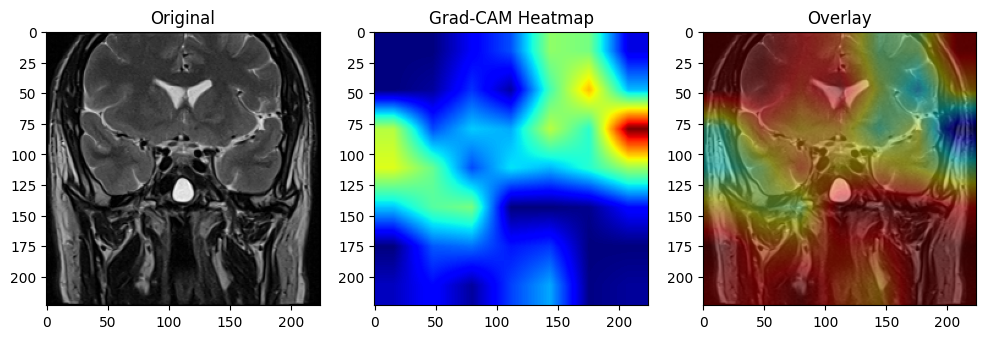

In [5]:
def make_gradcam_heatmap(img_array, model, last_conv_layer_name, pred_index=None):
    grad_model = tf.keras.models.Model(
        [model.inputs], 
        [model.get_layer(last_conv_layer_name).output, model.output]
    )

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        if pred_index is None:
            pred_index = tf.argmax(predictions[0])
        class_channel = predictions[:, pred_index]

    grads = tape.gradient(class_channel, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)
    return heatmap.numpy(), predictions

def display_gradcam(heatmap, original_img, alpha=0.4):
    heatmap_resized = cv2.resize(heatmap, (original_img.shape[1], original_img.shape[0]))
    heatmap_color = cv2.applyColorMap(np.uint8(255 * heatmap_resized), cv2.COLORMAP_JET)
    overlay = cv2.addWeighted(heatmap_color, alpha, cv2.cvtColor(original_img, cv2.COLOR_GRAY2BGR), 1 - alpha, 0)
    
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 3, 1)
    plt.title("Original")
    plt.imshow(original_img, cmap='gray')
    
    plt.subplot(1, 3, 2)
    plt.title("Grad-CAM Heatmap")
    plt.imshow(heatmap_resized, cmap='jet')
    
    plt.subplot(1, 3, 3)
    plt.title("Overlay")
    plt.imshow(overlay)
    plt.show()

dicom_path = "/kaggle/input/images/1-2.dcm"

img_input, img_original = load_dicom_image(dicom_path)
heatmap, preds = make_gradcam_heatmap(img_input, model, last_conv_layer)

# Optional: decode class prediction
print("Top Prediction:", decode_predictions(preds.numpy())[0][0])

display_gradcam(heatmap, img_original)